In [ ]:
#1_ليش داسويه؟ علمود اعرف الشخص مقبول او لا .
#batch and suppervised and classifiction .
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#2_import data.
df = pd.read_csv("Loan_Approval.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
977,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
978,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
979,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN


In [ ]:
df.shape

(981, 13)

In [ ]:
df.describe()
#عرفت انه الcreditميحتاج اخذ ال mean مالته لان اصله كلامي .
#طبيعي الفرق بالدخل مال شخص بحيث يطلعلي قيم شاذة لازم لان هذا دخل الشخص نفسه .

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [ ]:
df.info()
#اكو هواي نقص بالاوتبوت .

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


In [ ]:
df.isnull().sum()
#عرفت انه اكو هواي كلش نقوصات و عرفتهن وين بالضبط .

,0
Loan_ID,0
Gender,24
Married,3
Dependents,25
Education,0
Self_Employed,55
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,27
Loan_Amount_Term,20


In [ ]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

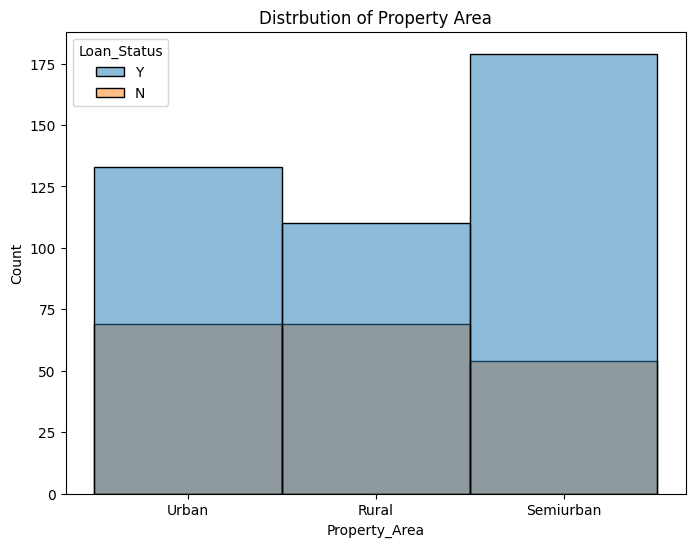

In [ ]:
#3_ Eda
#غالبا بالبداية نسوي هستوغرام نشوف التوزيع بعدين نسوي بار حتى نقارن .
plt.figure(figsize=(8,6))
sns.histplot(data = df , x= "Property_Area" , bins = 30 , hue = "Loan_Status") #اي رسمت اثنين عواميد لكن لازم نصي و واحد عددي .
plt.title("Distrbution of Property Area")
plt.show()
#عرفنا ان المناطق الريفية الموافقين بيها على القروض هم اقل فئة .
#في حين انه المناطق الشبه حضرية او مدنية يكونون مؤهلين اكثر ناسها للقروض و رفضهم اقل مقارنة ببقية المناطق.


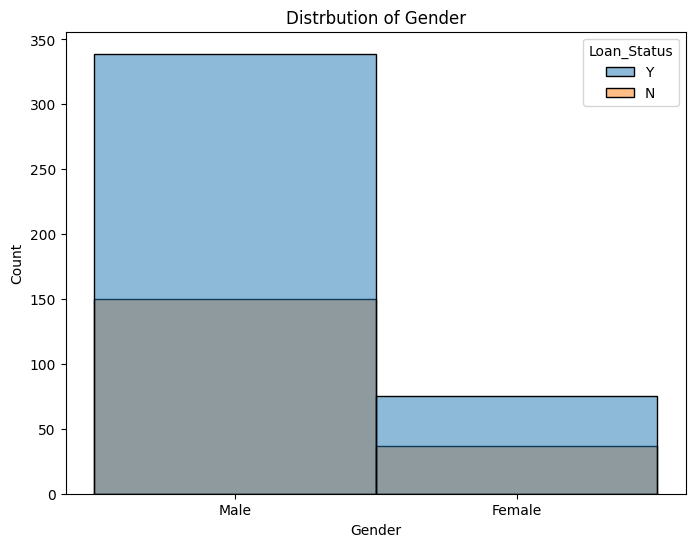

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data = df , x= "Gender" , bins = 30 , hue = "Loan_Status")
plt.title("Distrbution of Gender")
plt.show()
#كذلك هنا عرفنا انه الذكور اكثر من الاناث المؤهلين او المقبولين للقروض .

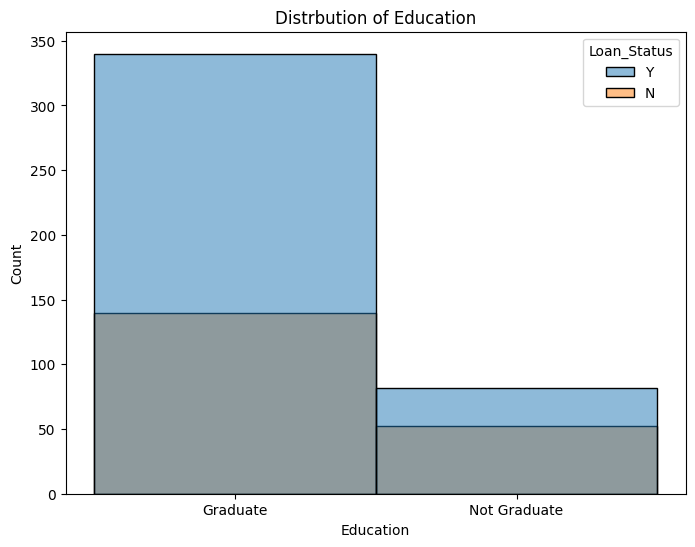

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data = df , x= "Education" , bins = 30 , hue = "Loan_Status")
plt.title("Distrbution of Education")
plt.show()
#كذلك عرفنا انه الخريجين هم الناس الاكثرية بالموافقة اوالتأهيل لسحب القروض.

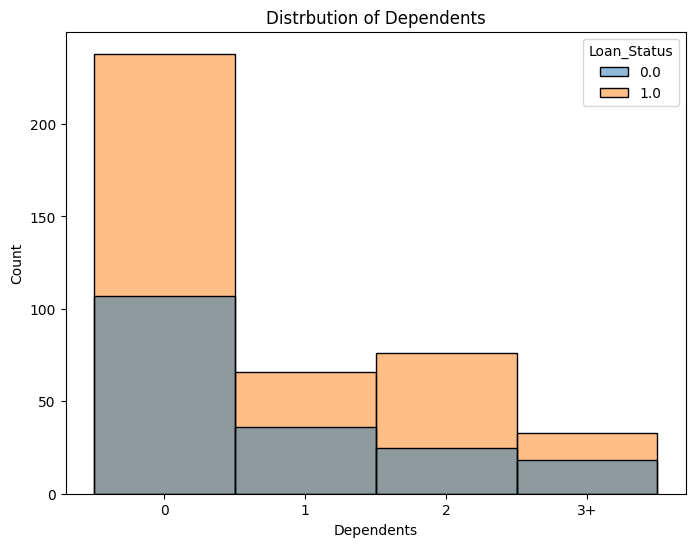

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data = df , x= "Dependents" , bins = 30 , hue = "Loan_Status")
plt.title("Distrbution of Dependents")
plt.show()
#عدد المعالين لكل عائلة (مثل الزوجة او الاطفال المعتمدين بشكل رسمي على راتب القرض او ميشتغلون) .
#كل ما قل عدد المعالين اي قلت مخاطرة عدم الدفع و راتب يكون كافي ف زيادة نسبة قبول المقترض .

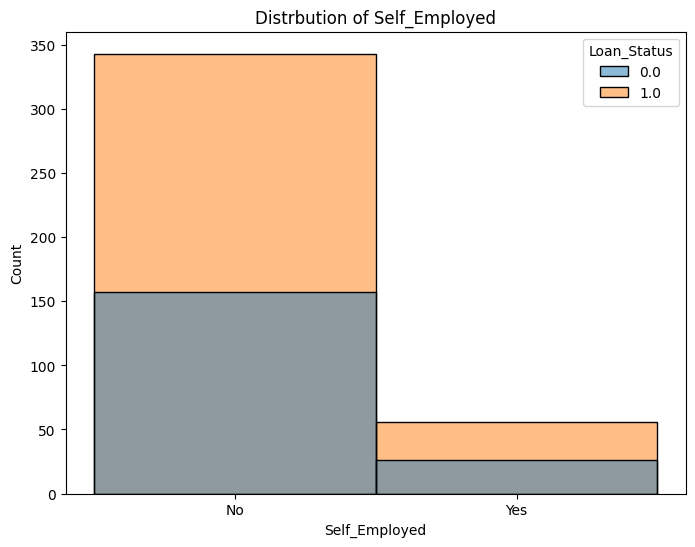

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data = df , x= "Self_Employed" , bins = 30 , hue = "Loan_Status")
plt.title("Distrbution of Self_Employed")
plt.show()
#اغلب الناس الموظفين او عايشين على راتب ثابت ذولة مخاطرتهم اقل من اصحاب المشاريع الخاصة بالدفع للقرض لذلك مقبولين .

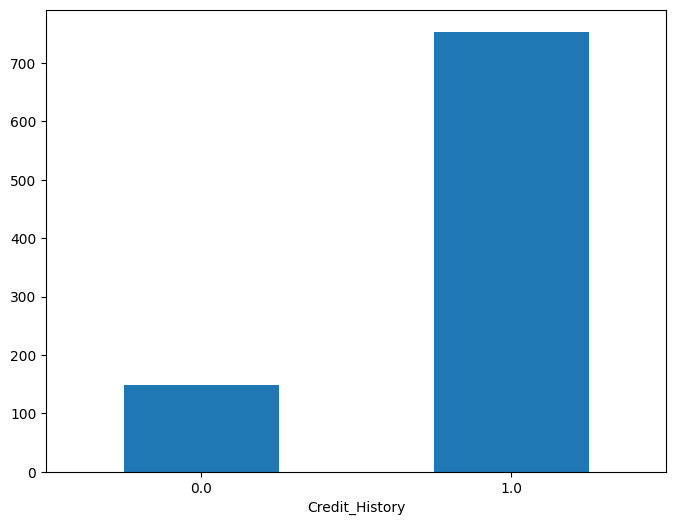

In [ ]:
plt.figure(figsize=(8,6))
df["Credit_History"].value_counts().sort_values(ascending=True).plot(kind = "bar")
plt.xticks(rotation = 0) #فريت كتابة الارقام او الاكس هنا بحيث صارلي افقي مو عمودي مكتوبات .
plt.show()
#ال1 يرمز للحركات المنتظمة ماليا للمقترض و الصفر يرمز للمقترض الحركاته المالية غير منتظمة .
#منطقيا انه الحركات المالية المنتظمة تعطي نسبة قبول عالية للمقترض عكس الناس الجدد او الحركات الغير منتظمة .
#اغلب المقترضين حركاتهم المالية منتظمة .

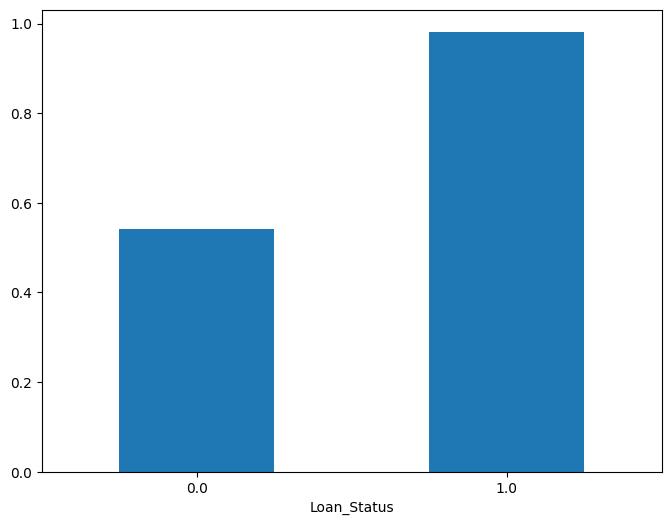

In [ ]:
plt.figure(figsize=(8,6))
df.groupby("Loan_Status")["Credit_History"].mean().sort_values(ascending=True).plot(kind = "bar")
plt.xticks(rotation = 0) #فريت كتابة الارقام او الاكس هنا بحيث صارلي افقي مو عمودي مكتوبات .
plt.show()
#نسبة قبول المقترضين المنظمة حركاتهم المالية اكثر من الغير منظمين بحركاتهم االمالية .

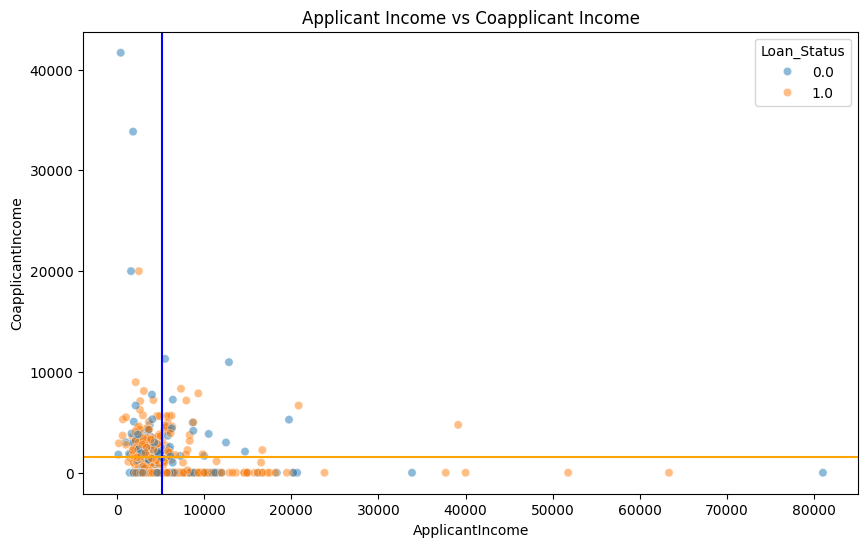

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data = df,
    x = "ApplicantIncome",
    y = "CoapplicantIncome",
    hue = "Loan_Status" ,
    alpha = 0.5
)
plt.axvline(x=df["ApplicantIncome"].mean() , color ="blue")
plt.axhline(y=df["CoapplicantIncome"].mean() , color = "orange")
plt.title("Applicant Income vs Coapplicant Income")
plt.show()
#اذا نباوع هنا علاقة مو قوية بيناتهم .
#كذلك الاغلب دخلهم 5000 تقريبا و الكفيل الاغلب دخله 2000 .

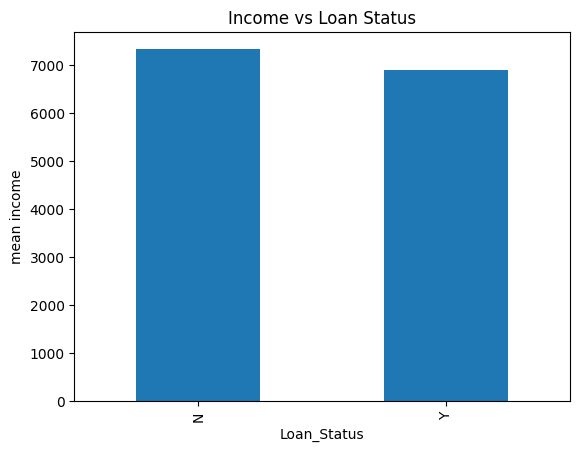

In [ ]:
df["income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df.groupby("Loan_Status")["income"].mean().plot(kind="bar")
plt.ylabel("mean income")
plt.title("Income vs Loan Status")
plt.show()
#سوينا عامود جديد و هو اجمالي الدخل للمقترض اي مجموع راتب الكفيل و راتب المقترض.
#ثم سوينا معدل اجمالي الدخل بالنسبة للاوتبوت , كذلك اثبتنا الرسم الفوكاه من حيث الارقام و المجموع بعلاقتهم .
#تقريبا اغلب المقبولين اجمالي دخلهم اقل من المرفوضين و هذا يعني اكو شروط اهم من اجمالي الدخل .

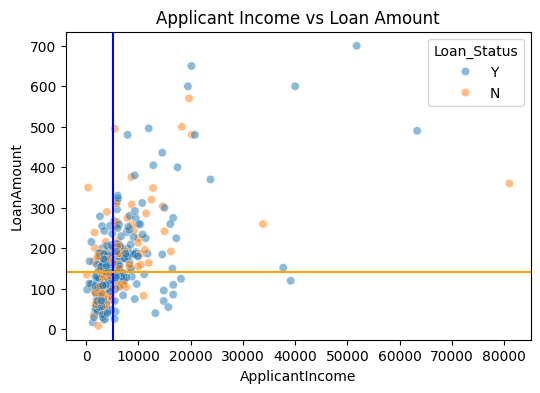

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='ApplicantIncome',
    y='LoanAmount',
    hue='Loan_Status',
    alpha = 0.5
)
plt.axvline(x=df["ApplicantIncome"].mean() , color="blue")
plt.axhline(y=df["LoanAmount"].mean() , color="orange")
plt.title('Applicant Income vs Loan Amount')
plt.show()
#اي كل ما زاد دخل المقترض زاد حجم القرض اللي يكدر يسحبه .
#اي انه القروض الحجمها كبير تقريبا اغلبها انقبلت و الاقل غالبا مرفوضة (كنظرة اولية ).

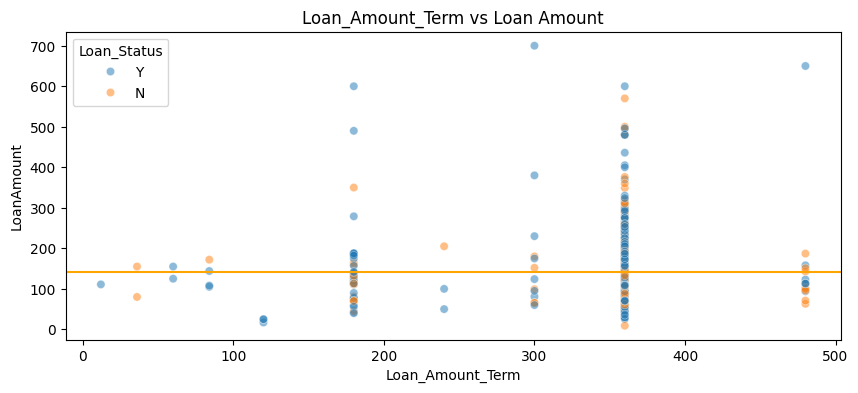

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(
    data=df,
    x='Loan_Amount_Term',
    y='LoanAmount',
    hue='Loan_Status',
    alpha = 0.5
)
plt.axhline(y=df["LoanAmount"].mean() , color="orange")
plt.title('Loan_Amount_Term vs Loan Amount')
plt.show()
#غالبية القروض هي لمدة سنة والاكثر من سنة قليلات كلش.
#كذلك اغلب القروض هي  150 الف الناس تسحبها اغلب شي .

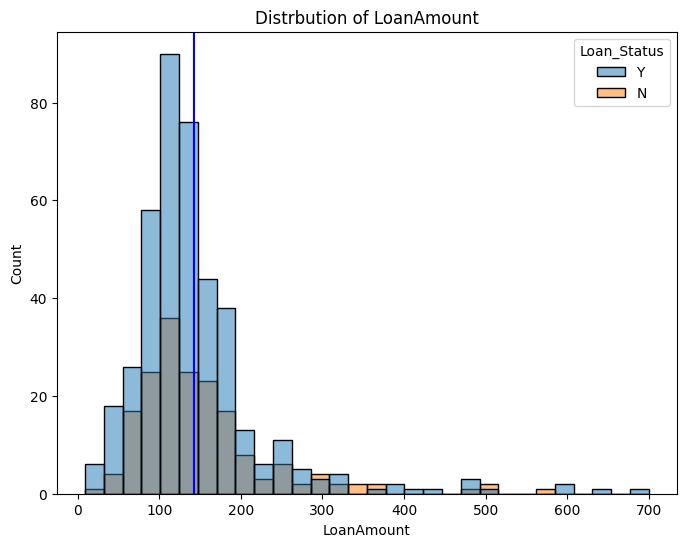

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data = df , x= "LoanAmount" , bins = 30 , hue = "Loan_Status")
plt.axvline(x=df["LoanAmount"].mean() , color="blue")
plt.title("Distrbution of LoanAmount")
plt.show()
#اذا هنا اكدنا انه اغلب القروض 150 لكن اغلب القروض المقبولة هي قروض ال 100 الف .
#كذلك اعلى معدل رفض على قروض ال 100 الف ايضا .

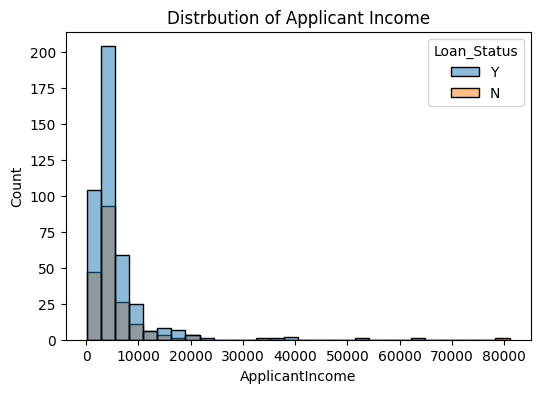

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=df,
    x='ApplicantIncome',
    hue="Loan_Status" ,
    bins = 30
)
plt.title("Distrbution of Applicant Income")
plt.show()
#معناها اغلب الدخلهم 5000 انقبلوا اي 200 نفر منهم انقبل و الانرفضوا 90 .
#هذا التحليل تابع لتحليل اجمالي الدخل لكن هذا وضحلنا انه من الاجمالي ف دخل الشخص يكون اهم من دخل الكفيل بنسبة القبول .

In [ ]:
df.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True) #N غير مقبول ف حطيتلها صفر و ال y مقبول ف حطيتلها واحد .
#دالة تسويلي انكودنك يدوي بداخل دكشنري حتى اني انطي الاولوية بيدي للمقبول و المرفوض ك 1 و 0 مو عشوائي.

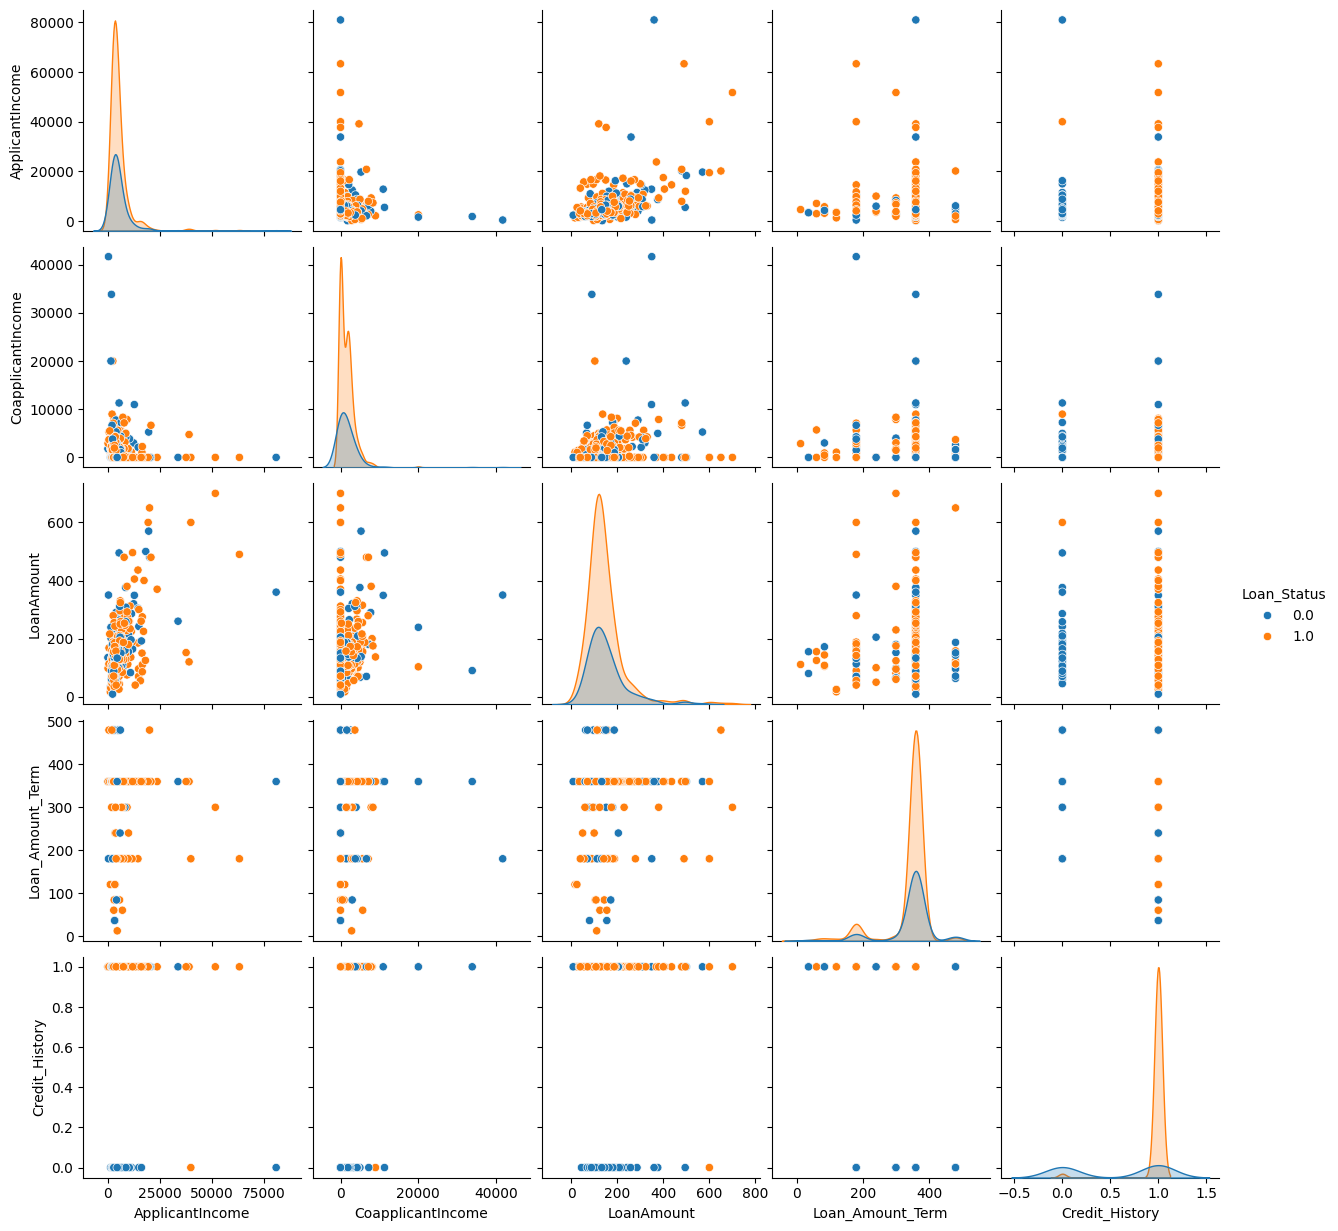

In [ ]:
sns.pairplot(
    df[[
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Loan_Status']],
    hue='Loan_Status'
)
plt.show()
#سويت علاقة بين الكل لكن حذفت الانبوت الكلامي .  ارفقت فقط العددي.

In [ ]:
correlation = df.corr(numeric_only=True)
#اخذت هنا دالة العلاقات حتى اشوف العلاقات بين العواميد الرقمية بالنسبة للاوتبوت .

In [ ]:
correlation["Loan_Status"].sort_values(ascending=False)
#اكتشفت انه اقوى عامود يأثرلي عالاوتبوت مثل ما توقعنا هو الحركات المالية لحساب المقترض .

,Loan_Status
Loan_Status,1.000000
Credit_History,0.561678
ApplicantIncome,-0.004710
Loan_Amount_Term,-0.021268
income,-0.031271
LoanAmount,-0.037318
CoapplicantIncome,-0.059187


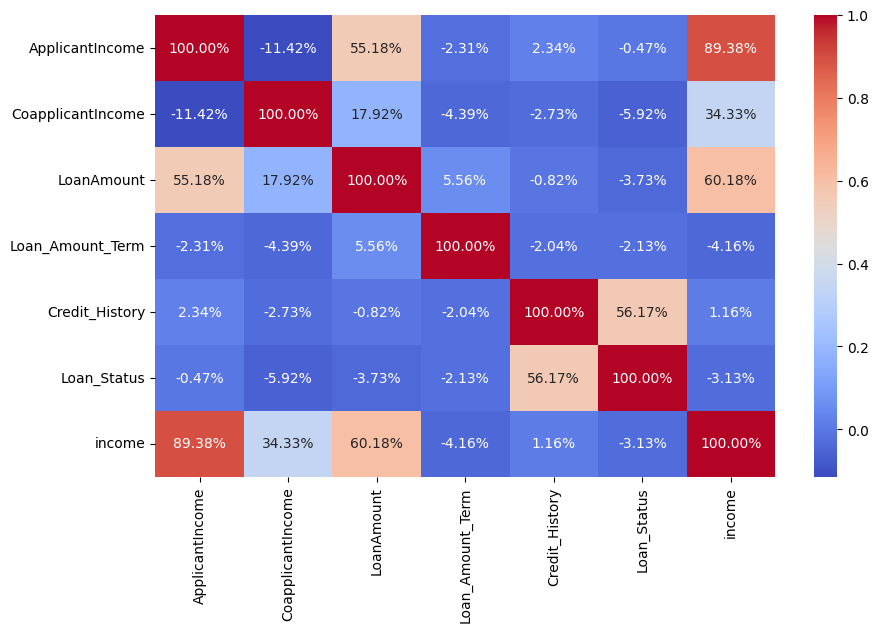

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation , annot=True ,fmt = ".2%" , cmap="coolwarm")
plt.show()
#هذا الجدول تقريبا اثبت كل فرضيات رسومنا الفوك كشفهن النا هنا و هن :
#علاقة الاوتبوت بالحركات المالية قوية جدا اي تأثير هذا العامود قوي جدا بتحديد اعطاء القرض.
#دخل المقترض تأثيره بصورة مباشرة في اجمالي الدخل اذا دخل الشخص يعتبر اهم بالنسبة لشروط القرض من دخل الكفيل.
#كذلك دخل الشخص يأثر بصورة مباشرة بحجم االقرض المراد سحبه و كذلك الاجمالي اكيد اكثر تأثيره.

In [ ]:
#4_feature engineering
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC #لان كلاسيفيكيشن ف نسميها هيج .

In [ ]:
df.drop("Loan_ID" , inplace=True , axis=1)
#حذفنا العامود الاول الكلامي (اي دي) لان ماحتاجه .

In [ ]:
df.dropna(inplace=True)
#مسحنا شكو NULL لان اغلبهن بالاوتبوت

In [ ]:
x = df.drop("Loan_Status" , axis=1)
y = df["Loan_Status"]
#قسمنا الانبوت و الاوتبوت .

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)
#قسمتهن كتدريب و ك اختبار .

In [ ]:
num_features = [
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
]
cat_features = ['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed','Property_Area']
 #صار عندي انبوت عددي و كلامي .
 #نلاحظ هنا بعض العواميد قيم بياناتهم صفر و واحد و خليناهم بالنصية لان ميفيدني انطيهم متوسط حسابي .
 #اي لان هن نصيات بس احنا معبرين عنهن ب ارقام صفر و واحد ف اضفتهن للبيانات النصية .

In [ ]:
num_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy="mean")),
    ("scaler" , StandardScaler())
])
cat_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy="most_frequent")),
    ("encoder" , OneHotEncoder(handle_unknown="ignore"))
])
#سويت البايب لاين الاول  و الثاني .
#كتله اتجاهلي شكو بيانات مراح تعرفها نصية مثل البيانات الناقصة .

In [ ]:
preprocesser = ColumnTransformer([
    ("num" , num_pipeline , num_features),
    ("cat" , cat_pipeline , cat_features)
])
#سويت البايب الثالث هنا .

In [162]:
#5_model and train
model_pipeline = Pipeline ([
    ("preprocessing" , preprocesser),
    ("model" , SVC(C =5 , kernel="poly" , degree=3 , coef0=1))
])
#البايب الرابع و الاخير اللي يجمع كلشي مع المودل.
#ال coef0 هو متغير ال R مال معادلة اللي يشوفني تأثير المعادلة داخليا .

#هذا احتمال من الاف الاحتمالات اختارينا بس نجرب هذا هنا .

In [163]:
model_pipeline.fit(x_train,y_train)
#تدريب المودل .

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('model', SVC(C=5, coef0=1, kernel='poly'))])

In [ ]:
y_pred = model_pipeline.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report

In [ ]:
f1 = f1_score(y_test , y_pred)
f1

0.8648648648648649

In [157]:
report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.75      0.43      0.55        28
         1.0       0.80      0.94      0.86        68

    accuracy                           0.79        96
   macro avg       0.78      0.68      0.71        96
weighted avg       0.79      0.79      0.77        96



In [172]:
#هسه لازم نستخدم خوارزمية تجربلي كل الاحتمالات الممكنة و تستخرجلي احسن احتمالية ب اعلى نتيجة .
L_poter = [
          {
              "model__kernel":["linear"],
              "model__C":[0.1 , 1 , 10]
          },#لهنا نطيته 3 احتمالات .
          {
              "model__kernel":["rbf"],
              "model__C":[0.1 , 1 , 10]
          },#لهنا عندي 6 احتمالات .
          {
              "model__kernel":["poly"],
              "model__C":[0.1 , 1 , 10],
              "model__degree":[2 , 3 , 4],
              "model__coef0":[0 , 1]
          }#لهنا صارن عندي بال 20 احتمال .
]
#سويت قائمة تضملي بداخلها قواميس او مجموعات بيانات كل قيمة مع مفتاحها .
#الفكرة انه هذي القائمة تضملي مجموعة من الاحتمالات حتى اطبق عليها بعدين و ناخذ الافضل .

In [173]:
#هسه الفكرة راح اقسم البيانات (كروس فالديشين) و اطبق عليهن الاحتمالات الفوك حتى اطلع افضل نتيجة بمعادلة ال F1 .
from sklearn.model_selection import GridSearchCV #مكتبة تسويلي البيانات اقسام و تبحثلي ب افضل احتمال .
grid_search = GridSearchCV( #هي هذي الدالة اللي تبحثلي ب افضل احتمال .
    estimator= model_pipeline, #المتغير الاخير مالتي العالجت بيه البيانات استدعيته حتى يطبق عليه .
    param_grid= L_poter ,#اي استدعيت الاحتمالات الاريد المودل يبحث ب افضل واحد بيهن عن طريق القائمة المسويها اله مالتهن .
    cv = 5, #عدد التقسيمات الاريدها .
    scoring = "f1" #تصنيف الافضل حسب هذي المعادلة حيحسبه .

)
#ب اختصار استدعينا مكتبة بيها دالة تسويلي تقطيع للبيانات ل 5 اقسام و طبقت الاحتمالات الكاتبهن الها وحدها و اختارت الافضل .
#اختارت الافضل حسب معادلة ال (اف 1 ) اي  يا هو اعلى سكور هو افضل احتمال تدريب لهذي البيانات و مناسب الها .
#اي بدل اعطاء المودل احتمال واحد يتدرب عليه اعطيناه كمية احتمالات و قلنا له اختار الافضل حسب شرط معين حتى ندربهن حسب هذا الاحتمال.

In [174]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['ApplicantIncome',
                                                                          'CoapplicantIncome',
                                                                          'LoanAmount',
                                                                          'Loan_Amount_Term',
                                                                          'Credit_History']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Gender',
                                                                          'Married',
                                                                          'Dependents',
                                                                          'Education',
                                                                          'Self_Employed',
                                                                          'Property_Area'])])),
                                       ('model',
                                        SVC(C=5, coef0=1, kernel='poly'))]),
             param_grid=[{'model__C': [0.1, 1, 10],
                          'model__kernel': ['linear']},
                         {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf']},
                         {'model__C': [0.1, 1, 10], 'model__coef0': [0, 1],
                          'model__degree': [2, 3, 4],
                          'model__kernel': ['poly']}],
             scoring='f1')

In [175]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
#اي اطبعلي افضل احتمالية شنو كانت تفاصيلها بقيم متغيراتها .
#كذلك اطبعلي افضل نتيجة كم كانت لهذه الاحتمالية ,اي ليش اختاريت هذي افضل خوارزمية .

Best Parameters: {'model__C': 0.1, 'model__kernel': 'linear'}
Best CV Score: 0.8734427300779462


In [176]:
best_model = grid_search.best_estimator_#هذي الصيغة تخزنلي المودل بمتغيراته كامله .
#اي طلعلي افضل مودل بمتغيراته و خزنه بمتغير اسمه (بيست مودل) .
y_pred = best_model.predict(x_test)
#اتوقعلي الاوتبوت مال انبوت التيست بعد تدريب المودل الجديد .

In [177]:
report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       1.00      0.39      0.56        28
         1.0       0.80      1.00      0.89        68

    accuracy                           0.82        96
   macro avg       0.90      0.70      0.73        96
weighted avg       0.86      0.82      0.79        96

